In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2
import librosa
from scipy.signal import find_peaks, savgol_filter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from moviepy.editor import VideoFileClip
from mmpose.apis import MMPoseInferencer
import json
import csv
import pickle

# ---------------------------------------------------------
# Module 1: Audio Anchor
# ---------------------------------------------------------
class AudioSynchronizer:
    def __init__(self, threshold_percentile=60):
        """
        Initialize the AudioSynchronizer.
        :param threshold_percentile: The percentile used to calculate the adaptive threshold for music onset.
        """
        self.threshold = threshold_percentile

    def extract_audio_array(self, video_path):
        """
        Extracts the audio track from a video and loads it as a numpy array.
        This prevents repeated I/O operations by extracting the audio only once.
        """
        print(f"   🎧 Extracting Audio Track for Analysis: {os.path.basename(video_path)}")
        temp_audio_path = f"temp_audio_{os.path.basename(video_path)}.wav"
        
        try:
            video_clip = VideoFileClip(video_path)
            if video_clip.audio is None:
                print("      ⚠️ No audio track found. Defaulting to full duration.")
                video_clip.close()
                return None, None, video_clip.duration
                
            # Export temporarily to WAV for librosa compatibility
            video_clip.audio.write_audiofile(temp_audio_path, logger=None)
            total_duration = video_clip.duration
            video_clip.close()
            
            # Load with librosa at 16kHz for faster processing
            y, sr = librosa.load(temp_audio_path, sr=22050)
            
            # Burn after reading: clean up temporary file
            if os.path.exists(temp_audio_path):
                os.remove(temp_audio_path)
                
            return y, sr, total_duration
            
        except Exception as e:
            print(f"      ❌ Audio extraction failed: {e}")
            if os.path.exists(temp_audio_path):
                os.remove(temp_audio_path)
            return None, None, None

    def find_music_start_time(self, y, sr):
        """
        Extracts audio from the video and automatically locates the true starting point
        of the accompaniment music using RMS energy analysis.

        :return: Music start time in seconds (float).
        """
        # print(f"[Module 1] 🎵 Extracting audio track from {os.path.basename(video_path)}...")

        try:
            # video_clip = VideoFileClip(video_path)

            # # If no audio track exists, return 0.0 immediately
            # if video_clip.audio is None:
            #     print("   ⚠️ No audio track found. Defaulting to 0.0s.")
            #     return 0.0
            
            # temp_audio_path = f"temp_audio_{os.path.basename(video_path)}.wav"

            # # Temporarily export the audio track as a wav file for librosa to process
            # video_clip.audio.write_audiofile(temp_audio_path, logger=None)

            # print("[Module 1] 🎵 Analyzing audio features...")
            # # Load audio using librosa. sr=22050 is a standard sampling rate for general analysis
            # y, sr = librosa.load(temp_audio_path, sr=22050)

            if y is None: return 0.0

            # 1. Calculate Root Mean Square (RMS) energy.
            # A frame_length of 2048 corresponds to roughly 0.1 seconds of audio.
            rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
            frames_to_time = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=512)

            # 2. Set an adaptive threshold based on the global audio energy distribution.
            # Using the 80th percentile acts as a robust criterion for sustained loud sounds (music).
            adaptive_threshold = np.percentile(rms, self.threshold)

            music_start_time = 0.0

            # 3. Search for the onset of "sustained high energy"
            # This logic filters out brief spikes like applause, coughs, or footsteps.
            for i, energy in enumerate(rms):
                if energy > adaptive_threshold:
                    # Look ahead for approximately 3 seconds (about 130 audio frames at hop_length=512)
                    future_window = rms[i:i+130]

                    # If the average energy of the upcoming 3 seconds is also high,
                    # it confirms this is continuous music, not a fleeting noise artifact.
                    if np.mean(future_window) > adaptive_threshold * 0.7:
                        music_start_time = frames_to_time[i]
                        break

        except Exception as e:
            print(f"[Module 1] ⚠️ Error processing audio: {e}")
            music_start_time = 0.0 # Fallback to 0 if audio extraction fails

        # finally:
        #     # Clean up the temporary audio file to free up storage
        #     if os.path.exists(temp_audio_path):
        #         os.remove(temp_audio_path)

        print(f" 🎵 Successfully locked music onset at: {music_start_time:.2f} seconds")
        return music_start_time

    def find_music_end_time(self, y, sr, total_duration, buffer_sec=2.0):
        """
        Precisely trims curtain call applause and ignores mid-performance pauses 
        using joint RMS (Energy) and ZCR (Zero-Crossing Rate) detection.
        """
        if y is None: return total_duration

        hop_length = 512
        rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=hop_length)[0]
        zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=2048, hop_length=hop_length)[0]

        # Normalize features to [0, 1] for thresholding
        rms_norm = rms / (np.max(rms) + 1e-8)
        zcr_norm = zcr / (np.max(zcr) + 1e-8)

        # Smooth signals to prevent micro-jitter misjudgments (1-second window)
        window_size = sr // hop_length 
        rms_smooth = np.convolve(rms_norm, np.ones(window_size)/window_size, mode='same')
        zcr_smooth = np.convolve(zcr_norm, np.ones(window_size)/window_size, mode='same')

        # Dynamically calculate applause ZCR threshold
        zcr_threshold = np.mean(zcr_smooth) + 0.5 * np.std(zcr_smooth)
        
        # Condition: Volume must not be pure silence AND ZCR must be low (excludes applause)
        music_mask = (rms_smooth > 0.05) & (zcr_smooth < zcr_threshold)

        valid_indices = np.where(music_mask)[0]
        times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

        if len(valid_indices) > 0:
            last_music_idx = valid_indices[-1]
            last_music_time = times[last_music_idx]
            
            # Add a buffer to preserve the reverb/decay of the final note
            end_time = min(last_music_time + buffer_sec, total_duration)
            print(f" 🎵 Detected End of Music: {end_time:.2f}s (Total: {total_duration:.2f}s)")
            return end_time
        else:
            print(" ⚠️ Could not confidently detect music end. Using full duration.")
            return total_duration

# ---------------------------------------------------------
# Module 2: Spatial Normalizer
# ---------------------------------------------------------
class SpatialNormalizer:
    def __init__(self):
        """
        Initializes the Spatial Normalizer for 3D skeleton sequences.
        Designed for Human3.6M topology (17 joints).
        """
        pass

    def normalize_sequence(self, skeletons_3d):
        """
        Executes full 3D spatial normalization to eliminate global translation, 
        and scale variances. Extracts scale-invariant height.
        
        Args:
            skeletons_3d (np.ndarray): Raw 3D coordinates. Shape: (T, 17, 3).
            
        Returns:
            tuple: 
                - skels_norm (np.ndarray): Aligned skeletons keeping rotation.
        """
        print("   📐 Executing Full Spatial Normalization (Root -> Scale)...")
        
        T, num_joints, dims = skeletons_3d.shape

        skels_norm = np.zeros_like(skeletons_3d)

        # Root Alignment (Translation Invariance)
        skels_rooted = skeletons_3d - skeletons_3d[:, 0:1, :]  # (T, J, 3)

        # Scale Normalization (Scale Invariance)
        spine_lengths = np.linalg.norm(
            skels_rooted[:, 9, :],   
            axis=1
        ) 
        
        median_spine_length = np.median(spine_lengths)

        if median_spine_length < 1e-5:
            return skels_rooted  # fallback

        skels_norm = skels_rooted / median_spine_length
            
        return skels_norm
    
# ====================================================
# Module 3: Arabesque Detection & Feature Engineering
# ====================================================
class ArabesquePeakDetector:
    def __init__(self, fps=30):
        self.fps = fps
        # Topology indices (e.g., Human3.6M)
        self.PELVIS = 0
        self.R_HIP, self.R_KNEE, self.R_ANKLE = 1, 2, 3
        self.L_HIP, self.L_KNEE, self.L_ANKLE = 4, 5, 6
        self.SPINE = 7
        self.THORAX = 8
        self.NECK = 9
        self.HEAD = 10
        self.L_SHOULDER, self.L_ELBOW, self.L_WRIST = 11, 12, 13
        self.R_SHOULDER, self.R_ELBOW, self.R_WRIST = 14, 15, 16 

    def _angle_between(self, v1, v2):
        """Calculate the angle (in degrees) between two 3D vectors."""
        n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if n1 < 1e-6 or n2 < 1e-6: return 0.0
        dot_product = np.clip(np.dot(v1 / n1, v2 / n2), -1.0, 1.0)
        return float(np.degrees(np.arccos(dot_product)))

    def _angle_with_vertical(self, vec, vertical_axis_idx, gravity_sign):
        """Calculate the angle between a given vector and the gravity/vertical axis."""
        vert_vec = np.zeros(3)
        vert_vec[vertical_axis_idx] = gravity_sign
        return self._angle_between(vec, vert_vec)

    def _is_skeleton_valid(self, skel):
        """
        Check if the skeleton is reasonable.
        """
        checks = [
            # (Joint A, Joint B, Max Distance)
            (self.PELVIS,  self.L_HIP,    0.4),
            (self.PELVIS,  self.R_HIP,    0.4),
            (self.L_HIP,   self.L_KNEE,   0.8),
            (self.R_HIP,   self.R_KNEE,   0.8),
            (self.L_KNEE,  self.L_ANKLE,  0.8),
            (self.R_KNEE,  self.R_ANKLE,  0.8),
            (self.PELVIS,  self.NECK,     1.2),
        ]
        for a, b, max_dist in checks:
            if np.linalg.norm(skel[a] - skel[b]) > max_dist:
                return False
        return True
    

    def evaluate_frame_features(self, skel, vertical_axis_idx, gravity_sign):
        """
        Extract 6 physical features from a single 3D skeleton frame and compute a weighted score.
        """
        if not self._is_skeleton_valid(skel):
            return 0.0, 0.0, {}

        # 1. Identify the working leg (the leg with the higher ankle)
        # Note: Multiply by gravity_sign to ensure larger values mean 'higher'
        def rel_height(idx):
            return (skel[idx][vertical_axis_idx] - skel[self.PELVIS][vertical_axis_idx]) * gravity_sign

        l_ank_h = rel_height(self.L_ANKLE)
        r_ank_h = rel_height(self.R_ANKLE)
        l_kne_h = rel_height(self.L_KNEE)
        r_kne_h = rel_height(self.R_KNEE)
        l_hip_h = rel_height(self.L_HIP)
        r_hip_h = rel_height(self.R_HIP)

        # Vote
        left_votes  = int(l_ank_h > r_ank_h) + int(l_kne_h > r_kne_h) + int(l_hip_h > r_hip_h)
        right_votes = 3 - left_votes
        
        if left_votes >= 2:
            raised_leg = 'Left'
            r_hip, r_knee, r_ank = self.L_HIP, self.L_KNEE, self.L_ANKLE
            s_hip, s_knee, s_ank = self.R_HIP, self.R_KNEE, self.R_ANKLE
            raised_height  = l_ank_h
            support_height = r_ank_h
        elif right_votes >= 2:
            raised_leg = 'Right'
            r_hip, r_knee, r_ank = self.R_HIP, self.R_KNEE, self.R_ANKLE
            s_hip, s_knee, s_ank = self.L_HIP, self.L_KNEE, self.L_ANKLE
            raised_height  = r_ank_h
            support_height = l_ank_h
        else:
            return 0.0, 0.0, {}

        # Feature 1: Foot height difference (Crucial for filtering Grand Jeté)
        foot_height_diff = raised_height - support_height

        # Feature 2: Support leg grounded check
        # In normalized coords, the grounded ankle should be well below the pelvis 
        is_jumping = support_height > -0.5 

        # Feature 3: Knee extension angles
        r_knee_angle = self._angle_between(skel[r_hip] - skel[r_knee], skel[r_ank] - skel[r_knee])
        s_knee_angle = self._angle_between(skel[s_hip] - skel[s_knee], skel[s_ank] - skel[s_knee])

        # Feature 4: Arabesque angle (Angle between Raised Leg and Torso with Hip as vertex)
        vec_leg = skel[r_ank] - skel[r_hip]
        vec_torso = skel[self.NECK] - skel[self.PELVIS]
        arabesque_angle = self._angle_between(vec_leg, vec_torso)

        # Feature 5: Torso forward tilt angle
        torso_tilt = self._angle_with_vertical(vec_torso, vertical_axis_idx, gravity_sign)

        # Feature 6: Depth check (Is the raised leg behind the body?)
        # Calculate the forward normal vector of the body
        def get_unit_vec(v):
            norm = np.linalg.norm(v)
            return v / norm if norm > 1e-6 else v
        
        pelvis_vec = get_unit_vec(skel[self.L_HIP] - skel[self.R_HIP])
        shoulder_vec = get_unit_vec(skel[self.L_SHOULDER] - skel[self.R_SHOULDER])
        spine_vec = get_unit_vec(skel[self.NECK] - skel[self.PELVIS])
        forward_vec = get_unit_vec(np.cross(pelvis_vec, spine_vec))

        back_extension = -np.dot(vec_leg, forward_vec)
        side_extension = abs(np.dot(vec_leg, pelvis_vec))
        
        # Project the raised leg vector onto the forward vector
        leg_forward_proj = np.dot(vec_leg, forward_vec)
        is_behind_body = (leg_forward_proj < 0) and (back_extension > 0.1)

        # Feature 7: Grab leg
        l_wrist_z = skel[self.L_WRIST][vertical_axis_idx] * gravity_sign
        r_wrist_z = skel[self.R_WRIST][vertical_axis_idx] * gravity_sign

        if l_wrist_z > r_wrist_z:
            highest_wrist_idx = self.L_WRIST
            highest_shoulder_idx = self.L_SHOULDER
        else:
            highest_wrist_idx = self.R_WRIST
            highest_shoulder_idx = self.R_SHOULDER

        dist_highest_wrist_ank = np.linalg.norm(skel[highest_wrist_idx] - skel[r_ank])

        # Feature 8: Elbow extension 
        l_elbow_angle = self._angle_between(skel[self.L_SHOULDER] - skel[self.L_ELBOW], skel[self.L_WRIST] - skel[self.L_ELBOW])
        r_elbow_angle = self._angle_between(skel[self.R_SHOULDER] - skel[self.R_ELBOW], skel[self.R_WRIST] - skel[self.R_ELBOW])

        # Feature 9: Arm vertical angle
        highest_arm_vec = skel[highest_wrist_idx] - skel[highest_shoulder_idx]
        up_vec = np.zeros(3)
        up_vec[vertical_axis_idx] = gravity_sign
        highest_arm_vertical_angle = self._angle_between(highest_arm_vec, up_vec)

        # Feature 10: Forward reach
        l_arm_forward = np.dot(skel[self.L_WRIST] - skel[self.L_SHOULDER], forward_vec)
        r_arm_forward = np.dot(skel[self.R_WRIST] - skel[self.R_SHOULDER], forward_vec)
        max_arm_forward = max(l_arm_forward, r_arm_forward)

        # Features for evolution analysis
        horizontal_indices = [i for i in range(3) if i != vertical_axis_idx]

        # 1. Pelvic Anterior Tilt
        pelvis_to_spine = skel[self.SPINE] - skel[self.PELVIS]
        pelvic_tilt = self._angle_with_vertical(pelvis_to_spine, vertical_axis_idx, gravity_sign)

        # 2. Lumbar Arch
        spine_to_thorax = skel[self.THORAX] - skel[self.SPINE]
        lumbar_arch = self._angle_between(pelvis_to_spine, spine_to_thorax)

        # 3. Thoracic-Neck Line
        thorax_to_neck = skel[self.NECK] - skel[self.NECK]
        neck_to_head = skel[self.HEAD] - skel[self.NECK]
        thoracic_neck_line = self._angle_between(thorax_to_neck, neck_to_head)

        # 4. Absolute Split Angle (Leg span)
        support_leg_vec = skel[s_ank] - skel[s_hip]
        raised_leg_vec = skel[r_ank] - skel[r_hip]
        split_angle = self._angle_between(support_leg_vec, raised_leg_vec)

        # 5. Support Leg Plumb Line
        support_up_vec = skel[s_hip] - skel[s_ank]
        support_leg_plumb = self._angle_with_vertical(support_up_vec, vertical_axis_idx, gravity_sign)

        # 6. Shoulder-Hip Torsion
        pelvis_vec_2d = (skel[self.L_HIP] - skel[self.R_HIP])[horizontal_indices]
        shoulder_vec_2d = (skel[self.L_SHOULDER] - skel[self.R_SHOULDER])[horizontal_indices]
        shoulder_hip_torsion = self._angle_between(pelvis_vec_2d, shoulder_vec_2d)

        # 7. Arm Horizontal Symmetry
        arm_symmetry = abs(skel[self.L_WRIST][vertical_axis_idx] - skel[self.R_WRIST][vertical_axis_idx])

        # 8. Pelvic Openness
        forward_vec_2d = forward_vec[horizontal_indices]
        pelvic_openness_angle = self._angle_between(pelvis_vec_2d, forward_vec_2d)

        # ==========================================
        # Composite Scoring System (Max Score: 1.0)
        # ==========================================
        score = 0.0
        
        # A. Hard Gates (Eliminate clear non-arabesque poses)
        if is_jumping or foot_height_diff < 0.15 or raised_height < -0.9:
            return 0.0, raised_height, {}
        
        if dist_highest_wrist_ank < 0.75:
            return 0.0, raised_height, {}

        # B. Soft Weighted Scoring
        # 1. Raised leg height (Weight: 0.25)
        score += np.clip((raised_height + 0.3) / 0.8, 0, 1) * 0.25
        
        # 2. Arabesque angle (<80 deg gets full points) (Weight: 0.2)
        score += np.clip((140 - arabesque_angle) / 50, 0, 1) * 0.2
        
        # 3. Raised knee extension (>150 deg gets full points) (Weight: 0.15)
        score += np.clip((r_knee_angle - 120) / 30, 0, 1) * 0.15

        # 4. Forward reach (Weight: 0.1)
        score += np.clip(max_arm_forward / 0.2, 0, 1) * 0.1
        
        # 5. Torso tilt (Appropriate tilt adds score, extreme tilt penalized) (Weight: 0.15)
        if 10 < torso_tilt < 90:
            score += 0.15
        
        # 6. Leg behind body bonus (Weight: 0.15)
        if is_behind_body:
            score += 0.15

        metrics = {
            'raised_leg': raised_leg,
            'raised_height': float(raised_height),
            'foot_height_diff': float(foot_height_diff),
            'arabesque_angle': float(arabesque_angle),
            'torso_tilt': float(torso_tilt),
            'raised_knee_angle': float(r_knee_angle),
            'support_knee_angle': float(s_knee_angle),
            'dist_highest_wrist_ank': float(dist_highest_wrist_ank),
            'l_elbow_angle': float(l_elbow_angle),
            'r_elbow_angle': float(r_elbow_angle),
            'highest_arm_vertical_angle': float(highest_arm_vertical_angle),
            'max_arm_forward': float(max_arm_forward),
            'is_behind_body': bool(is_behind_body),
            'back_extension': float(back_extension),
            'is_jumping': bool(is_jumping),
            'pelvic_tilt': float(pelvic_tilt),
            'lumbar_arch': float(lumbar_arch),
            'thoracic_neck_line': float(thoracic_neck_line),
            'split_angle': float(split_angle),
            'support_leg_plumb': float(support_leg_plumb),
            'shoulder_hip_torsion': float(shoulder_hip_torsion),
            'arm_symmetry': float(arm_symmetry),
            'pelvic_openness_angle': float(pelvic_openness_angle)
        }
        
        return score, raised_height, metrics

    def detect_peaks(self, skels_norm, score_threshold=0.6):
        """
        Identify kinematic peak frames across the entire video sequence.
        """
        T = len(skels_norm)
        if T == 0: return []
        
        # Determine gravity direction based on median posture
        median_skel = np.median(skels_norm, axis=0)
        v_spine_median = median_skel[self.NECK] - median_skel[self.PELVIS]
        vertical_axis_idx = np.argmax(np.abs(v_spine_median))
        gravity_sign = np.sign(v_spine_median[vertical_axis_idx])
        # vertical_axis_idx = 1
        # gravity_sign = -1

        raw_heights = np.zeros(T)
        frame_scores = np.zeros(T)
        frame_metrics = []

        # Extract features frame by frame
        for t in range(T):
            score, height, metrics = self.evaluate_frame_features(
                skels_norm[t], vertical_axis_idx, gravity_sign
            )
            raw_heights[t] = height
            frame_scores[t] = score
            frame_metrics.append(metrics)

        # Apply Savitzky-Golay filter to smooth the kinematic trajectory (noise reduction)
        window = int(self.fps * 0.8) | 1 # Ensure odd number
        if window > T: window = T | 1 if (T | 1) < T else T - 1 if T % 2 == 0 else T
        if window < 3: window = 3
        
        smoothed_heights = savgol_filter(raw_heights, window, 3)

        # Detect local maxima (peaks) on the smoothed trajectory
        peaks, _ = find_peaks(smoothed_heights, prominence=0.15, distance=self.fps * 1.5)

        arabesque_frames = []
        for p in peaks:
            # Validate peak against the composite score threshold
            if frame_scores[p] >= score_threshold:
                arabesque_frames.append({
                    'frame_idx': int(p),
                    'timestamp': round(p / self.fps, 3),
                    'score': round(float(frame_scores[p]), 3),
                    'metrics': frame_metrics[p]
                })

        return arabesque_frames

# ==========================================
# Module 4: Arabesque Visualization
# ==========================================
class ArabesqueVisualizer:
    @staticmethod
    def draw_hud(frame, metrics, score):
        """
        Draw a semi-transparent Heads-Up Display (HUD) with Arabesque metrics.
        """
        h, w = frame.shape[:2]
        overlay = frame.copy()
        
        # Define HUD properties
        hud_w, hud_h = 400, 400
        x, y = 20, 20
        
        # Draw semi-transparent background
        cv2.rectangle(overlay, (x, y), (x + hud_w, y + hud_h), (0, 0, 0), -1)
        frame = cv2.addWeighted(overlay, 0.6, frame, 0.4, 0)
        
        # Define text properties
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        color_white = (255, 255, 255)
        color_green = (0, 255, 0)
        color_red = (0, 0, 255)
        thickness = 1
        line_type = cv2.LINE_AA

        # Title and Score
        cv2.putText(frame, f"Arabesque Detected | Score: {score:.2f}", (x + 15, y + 30), 
                    font, 0.7, color_green, 2, line_type)
        
        # Detailed Metrics
        lines = [
            f"Raised Leg: {metrics['raised_leg']}",
            f"Raised Height: {metrics['raised_height']:.2f}",
            f"Arabesque Angle: {metrics['arabesque_angle']:.1f} deg",
            f"Torso Tilt: {metrics['torso_tilt']:.1f} deg",
            f"Raised Knee Angle: {metrics['raised_knee_angle']:.1f} deg",
            f"Support Knee Angle: {metrics['support_knee_angle']:.1f} deg",
            f"Foot Height Diff: {metrics['foot_height_diff']:.2f}",
            f"L.Elbow Angle: {metrics['l_elbow_angle']:.1f} deg",
            f"R.Elbow Angle: {metrics['r_elbow_angle']:.1f} deg",
            f"Highest Wrist Ankle Dist: {metrics['dist_highest_wrist_ank']:.2f}",
            f"Highest Arm Vertical Angle: {metrics['highest_arm_vertical_angle']: .1f} deg",
            f"Max Arm Forward: {metrics['max_arm_forward']:.2f}",
            f"Back Extension: {metrics['back_extension']:.2f}",
        ]
        
        behind_body_text = f"Behind Body: {'YES' if metrics['is_behind_body'] else 'NO'}"
        lines.append(behind_body_text)

        for i, text in enumerate(lines):
            text_y = y + 65 + (i * 25)
            # Highlight 'Behind Body' condition
            if "YES" in text:
                cv2.putText(frame, text, (x + 15, text_y), font, font_scale, color_green, thickness, line_type)
            elif "NO" in text and "Behind" in text:
                cv2.putText(frame, text, (x + 15, text_y), font, font_scale, color_red, thickness, line_type)
            else:
                cv2.putText(frame, text, (x + 15, text_y), font, font_scale, color_white, thickness, line_type)
                
        return frame

    @staticmethod
    def extract_and_save_peak_frame(video_path, output_dir, peak_data, base_filename="video"):
        """
        Extract the specific frame from the video, draw HUD, and save as image.
        """
        os.makedirs(output_dir, exist_ok=True)
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error opening video file: {video_path}")
            return None

        frame_idx = peak_data['frame_idx']
        # Seek to the exact frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if ret:
            # Draw metrics HUD
            vis_frame = ArabesqueVisualizer.draw_hud(frame, peak_data['metrics'], peak_data['score'])
            
            # Save the frame
            out_path = os.path.join(output_dir, f"{base_filename}_frame_{frame_idx}_score_{peak_data['score']:.2f}.jpg")
            # cv2.imwrite(out_path, vis_frame)
            try:
                ext = os.path.splitext(out_path)[1]
                
                is_success, im_buf_arr = cv2.imencode(ext, vis_frame)
                if is_success:
                    im_buf_arr.tofile(out_path)
                    return True
                else:
                    print(f"❌ Image encoding fails.")
                    return False
            except Exception as e:
                print(f"❌ Error: {e}")
                return False
            cap.release()
            return out_path
        
        cap.release()
        return None

# ==========================================
# Main Pipeline
# ==========================================
def process_video_folder(input_folder, output_folder):
    print("==================================================")
    print("🚀 VIDEO ARCHIVE: BATCH PROCESSING ENGINE STARTED")
    print("==================================================")
    
    video_files = glob.glob(os.path.join(input_folder, "*.mp4"))
    if not video_files:
        print(f"❌ No .mp4 videos found in {input_folder}!")
        return
        
    print(f"📁 Found {len(video_files)} videos for processing.")
    
    # Initialize MMPose Engine ONCE to save VRAM and loading time
    # print("\n🧠 Loading MMPose DL Models into VRAM...")
    # inferencer_2d = MMPoseInferencer(pose2d='human', device='cuda:0')
    # inferencer_3d = MMPoseInferencer(pose2d='human', pose3d='human3d', device='cuda:0')
    
    audio_sync = AudioSynchronizer()
    
    # Global Data Pool
    global_features = []
    global_metadata = [] 
    
    for idx, video_path in enumerate(video_files):
        vid_name = os.path.basename(video_path)
        
        # Detect dynamic FPS for current video
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps < 1: fps = 30.0 # Fallback for corrupted metadata
        cap.release()
        
        print(f"\n[{idx+1}/{len(video_files)}] Processing Video: {vid_name} (FPS: {fps:.2f})")
        
        # Step 1: Audio Cropping
        y, sr, total_duration = audio_sync.extract_audio_array(video_path)
        music_start_sec = audio_sync.find_music_start_time(y, sr)
        music_end_sec = audio_sync.find_music_end_time(y, sr, total_duration, buffer_sec=1)
        temp_video_path = f"temp_trim_{vid_name}"
        
        try:
            print("   ✂️ Cropping pre-performance noise...")
            clip = VideoFileClip(video_path)
            trimmed_clip = clip.subclip(music_start_sec, music_end_sec)
            trimmed_clip.write_videofile(temp_video_path, codec="libx264", audio=True, logger=None)
            clip.close()
            
            # Step 2: 2D&3D Pose Inference (Bulletproof generator)
            # print("   👁️ Executing Pass 1: Extracting 2D Pixel Coordinates...")
            # all_2d_keypoints = []

            # for result in inferencer_2d(temp_video_path):
            #     preds = result.get('predictions', [])
            #     if len(preds) > 0 and len(preds[0]) > 0:
            #         all_2d_keypoints.append(preds[0][0]['keypoints'])
            #     else:
            #         all_2d_keypoints.append(all_2d_keypoints[-1] if all_2d_keypoints else np.zeros((17, 2)))

            print("   🦴 Extracting 3D Spatial Coordinates...")
            inferencer_3d = MMPoseInferencer(pose3d='human3d', device='cuda:0')
            all_3d_keypoints = []
            frozen_frames_count = 0
       
            for result in inferencer_3d(temp_video_path):
                preds = result.get('predictions', [])
                if len(preds) > 0 and len(preds[0]) > 0:
                    all_3d_keypoints.append(preds[0][0]['keypoints'])
                    frozen_frames_count = 0
                else:
                    all_3d_keypoints.append(all_3d_keypoints[-1] if all_3d_keypoints else np.zeros((17, 3)))
                    frozen_frames_count += 1
                    
                    if frozen_frames_count > 5:
                        print(f"      🚨 WARNING: 3D Model lost tracking for {frozen_frames_count} frames! Producing Zombie Frames!")

            # min_len = min(len(all_2d_keypoints), len(all_3d_keypoints))
            # skeletons_2d = np.array(all_2d_keypoints[:min_len])
            # skeletons_3d = np.array(all_3d_keypoints[:min_len])
            skeletons_3d = np.array(all_3d_keypoints)
            
            print(f"   ✅ Synchronized {len(skeletons_3d)} frames. 3D Shape: {skeletons_3d.shape[1:]}")
            
            if len(skeletons_3d) < 30:
                print("   ⏭️ Video too short after cropping. Skipping.")
                continue
                
            normalizer = SpatialNormalizer()
            skels_norm = normalizer.normalize_sequence(skeletons_3d)

            detector = ArabesquePeakDetector(fps=fps)
            peaks = detector.detect_peaks(skels_norm, score_threshold=0.4)
            
            if not peaks:
                print("   ⚠️ No Arabesque movements detected above threshold.")
                continue
                
            print(f"   🎯 Found {len(peaks)} Arabesque peaks. Saving data...")
            
            # Prepare list to store data for CSV
            csv_data = []
            frames_output_dir = os.path.join(output_folder, "frames")
            
            for i, peak in enumerate(peaks):
                # Extract, visualize, and save the frame
                img_path = ArabesqueVisualizer.extract_and_save_peak_frame(
                    video_path=temp_video_path,
                    output_dir=frames_output_dir,
                    peak_data=peak,
                    base_filename=f"{vid_name}_peak_{i}"
                )
                
                # Flatten the dictionary for CSV export
                row_data = {
                    'video': vid_name,
                    'peak_id': i,
                    'frame_idx': peak['frame_idx'],
                    'timestamp_sec': peak['timestamp'],
                    'total_score': peak['score'],
                    'image_path': img_path
                }
                # Merge metrics into the row
                row_data.update(peak['metrics'])
                csv_data.append(row_data)

            # 4. Save metrics to CSV using Pandas
            df = pd.DataFrame(csv_data)
            csv_path = os.path.join(output_folder, f"{vid_name}_arabesque_metrics.csv")
            df.to_csv(csv_path, index=False, encoding='utf-8')
            
            print(f"   ✅ Saved {len(peaks)} frames to {frames_output_dir}")
            print(f"   ✅ Saved metrics to {csv_path}\n")
                    
        except Exception as e:
            print(f"   ❌ Fatal error processing {vid_name}: {e}")
            continue
            
        finally:
            # Clean up temporary cropped video to save disk space
            if os.path.exists(temp_video_path):
                os.remove(temp_video_path)
    
    print("\n✅ Batch Processing Complete.")

### Run by module

In [9]:
input_folder = "./videos"
output_folder = "./results"

video_files = glob.glob(os.path.join(input_folder, "*.mp4"))

if not video_files:
    print(f"❌ No .mp4 videos found in {input_folder}!")
else:
    print(f"📁 Found {len(video_files)} videos for processing.")

📁 Found 1 videos for processing.


In [10]:
print("\n🧠 Global Initializing...")

audio_sync = AudioSynchronizer()

# Global Data Pool
global_features = []
global_metadata = [] 


🧠 Global Initializing...


In [11]:
def visualize_3d_skeleton(skeleton_3d, frame_idx=None, title="3D Arabesque Visualization"):
    """
    Visualize single-frame 3D skeleton joints (MMPose Human3.6M 17-joint topology).
    
    Parameters:
    skeleton_3d: numpy array of shape (17, 3), representing 3D coordinates for a single frame.
    frame_idx: Index of the frame (used for display in the title).
    """
    # install ipympl
    # %matplotlib widget 
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Human3.6M 17-keypoint standard skeleton connections (start_node, end_node)
    # Based on index mapping: 0:Pelvis, 1-3:Right Leg, 4-6:Left Leg, 9:Neck, 10:Head, 11-13:Left Arm, 14-16:Right Arm
    connections = [
        (0, 1), (1, 2), (2, 3),          # Right Leg (Pelvis -> R_Hip -> R_Knee -> R_Ankle)
        (0, 4), (4, 5), (5, 6),          # Left Leg (Pelvis -> L_Hip -> L_Knee -> L_Ankle)
        (0, 7), (7, 8), (8, 9), (9, 10), # Spine & Head (Pelvis -> Spine -> Thorax -> Neck -> Head)
        (9, 14), (14, 15), (15, 16),     # Right Arm (Neck -> R_Shoulder -> R_Elbow -> R_Wrist)
        (9, 11), (11, 12), (12, 13)      # Left Arm (Neck -> L_Shoulder -> L_Elbow -> L_Wrist)
    ]

    xs = skeleton_3d[:, 0]
    ys = skeleton_3d[:, 1]
    zs = skeleton_3d[:, 2] 

    ax.scatter(xs, ys, zs, c='red', s=40, label='Joints')
    
    # Highlight the Pelvis (Root) node with a large green star
    ax.scatter(xs[0], ys[0], zs[0], c='green', s=150, marker='*', label='Pelvis (Root)')

    # Draw skeleton connections (lines)
    for (start_idx, end_idx) in connections:
        if start_idx < len(skeleton_3d) and end_idx < len(skeleton_3d):
            ax.plot([xs[start_idx], xs[end_idx]], 
                    [ys[start_idx], ys[end_idx]], 
                    [zs[start_idx], zs[end_idx]], 
                    color='blue', linewidth=2.5)

    ax.set_xlabel('X (Left/Right Width)')
    ax.set_ylabel('Y (Front/Back Depth)')
    ax.set_zlabel('Z (Up/Down Height)')

    # Enforce equal aspect ratio across all three axes
    max_range = np.array([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()]).max() / 2.0
    mid_x = (xs.max()+xs.min()) * 0.5
    mid_y = (ys.max()+ys.min()) * 0.5
    mid_z = (zs.max()+zs.min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    # elev=15 (slight upward tilt), azim=-45 (diagonal view)
    ax.view_init(elev=15, azim=-45)

    plot_title = title if frame_idx is None else f"{title} - Frame {frame_idx}"
    plt.title(plot_title)
    plt.legend()
    plt.show()


[1/1] Processing Video: Jingxinyu.mp4 (FPS: 25.00)
   🎧 Extracting Audio Track for Analysis: Jingxinyu.mp4
 🎵 Successfully locked music onset at: 11.84 seconds
 🎵 Detected End of Music: 154.14s (Total: 170.97s)
   ✂️ Cropping pre-performance noise...
   🦴 Extracting 3D Spatial Coordinates...
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/body_3d_keypoint/pose_lift/h36m/motionbert_ft_h36m-d80af323_20230531.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
   ✅ Synchronized 3558 frames. 3D Shape: (17, 3))
   📐 Executing Full Spatial Normalization (Root -> Scale)...
   🎯 Found 17 Arabesque peaks. Saving data...


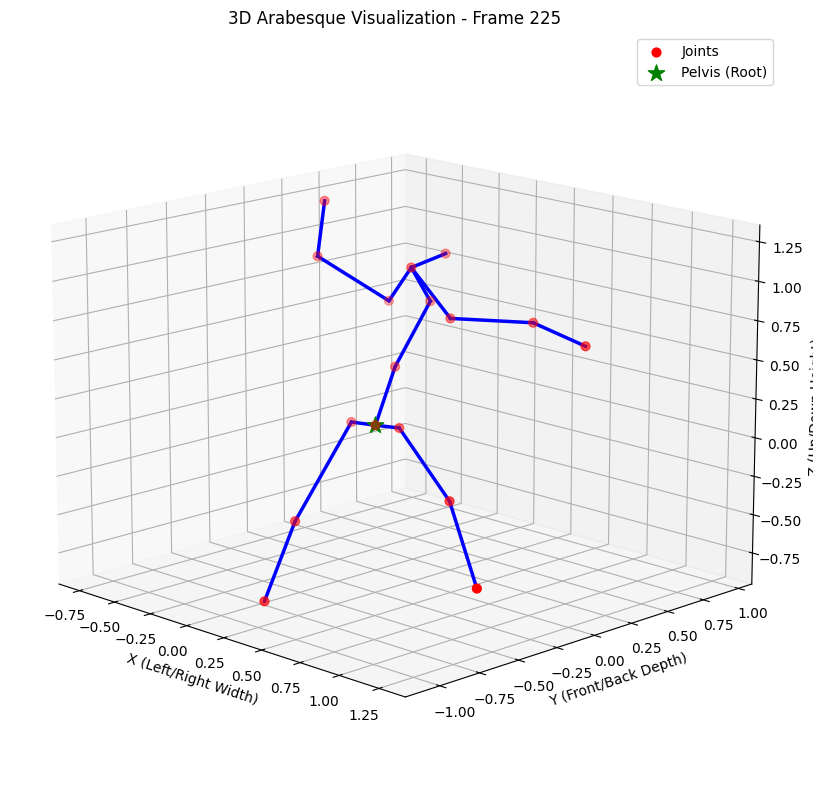

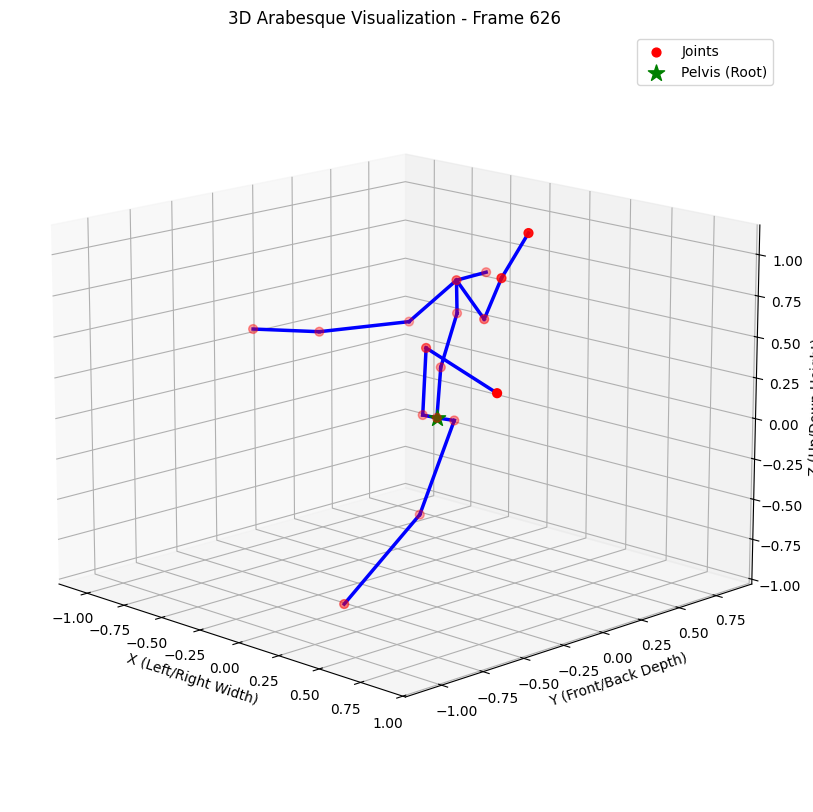

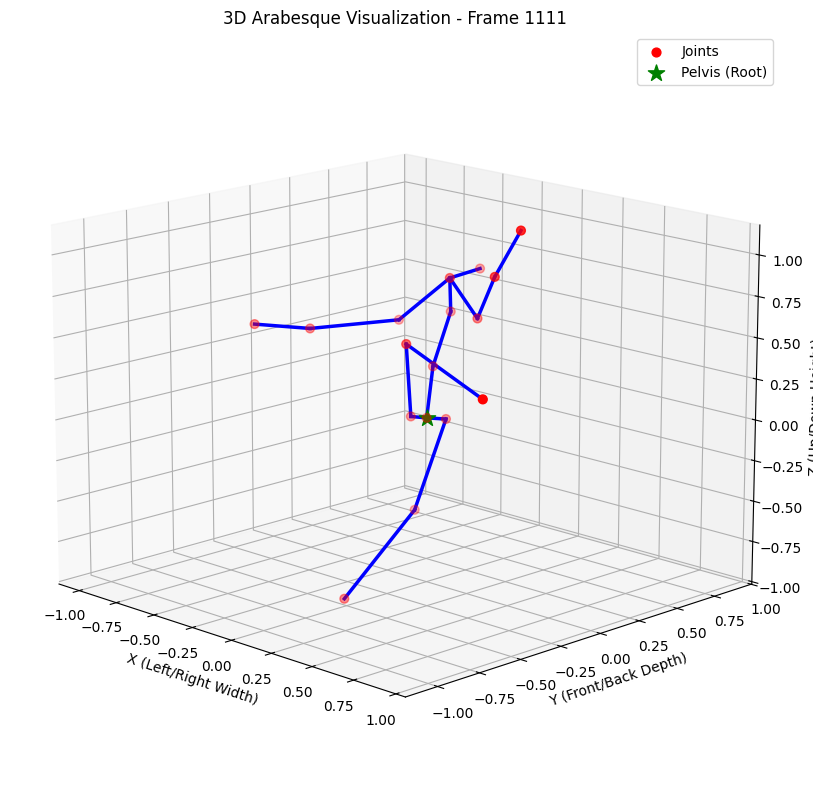

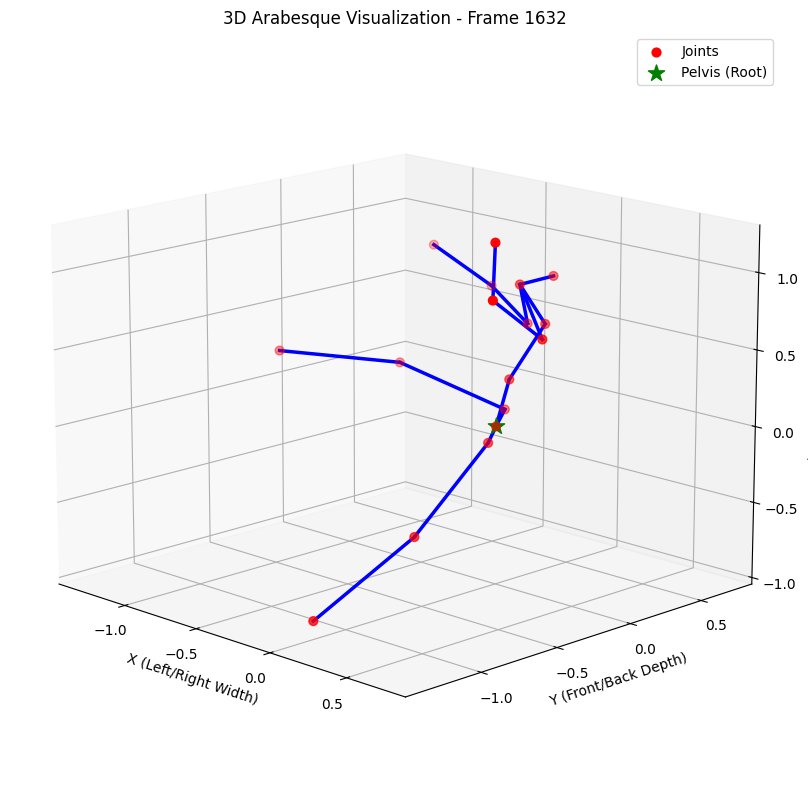

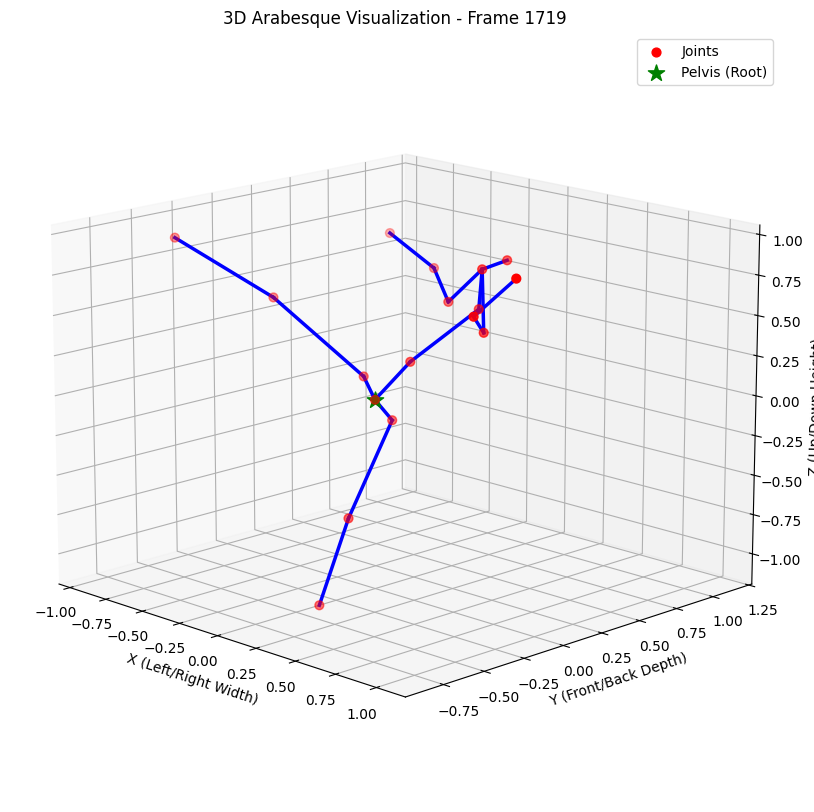

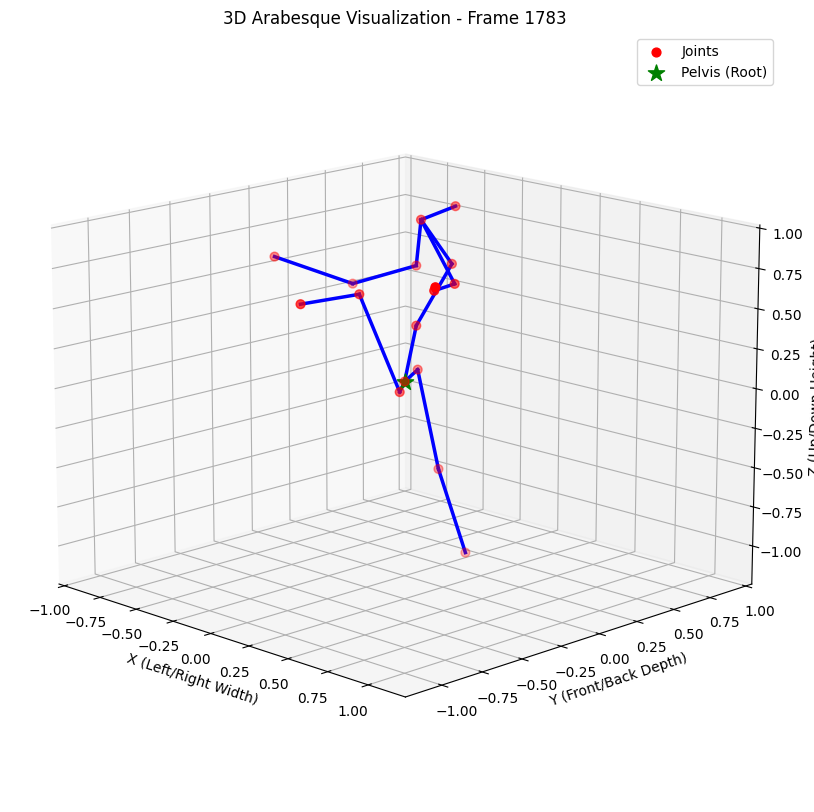

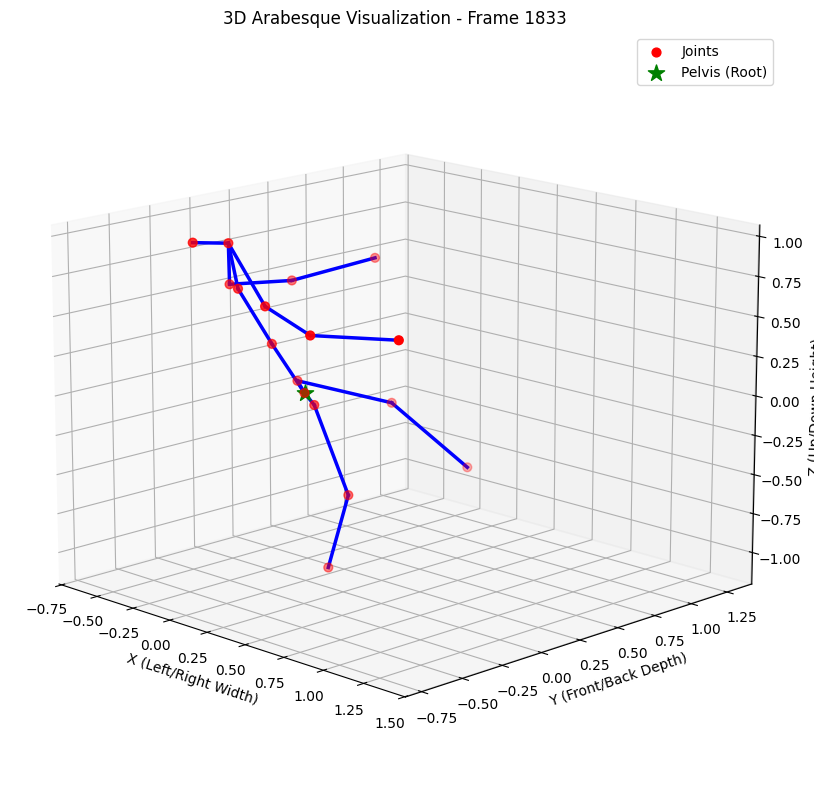

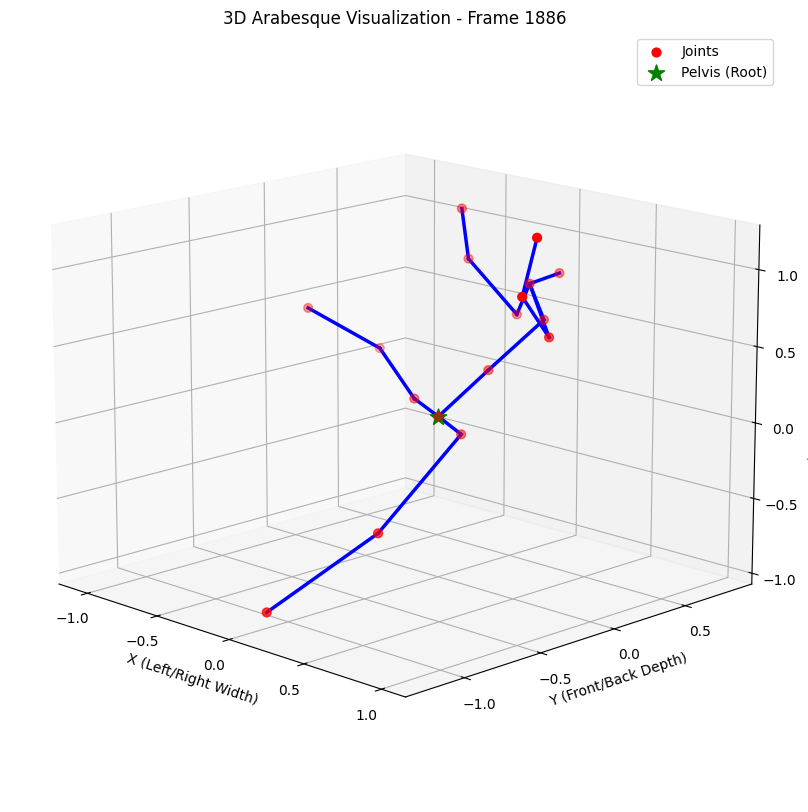

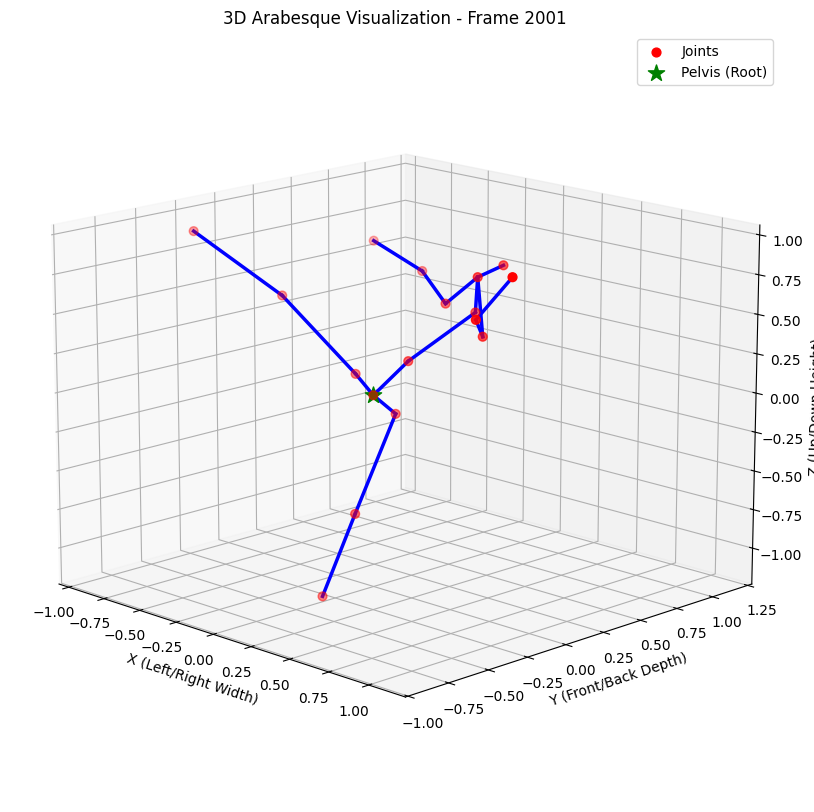

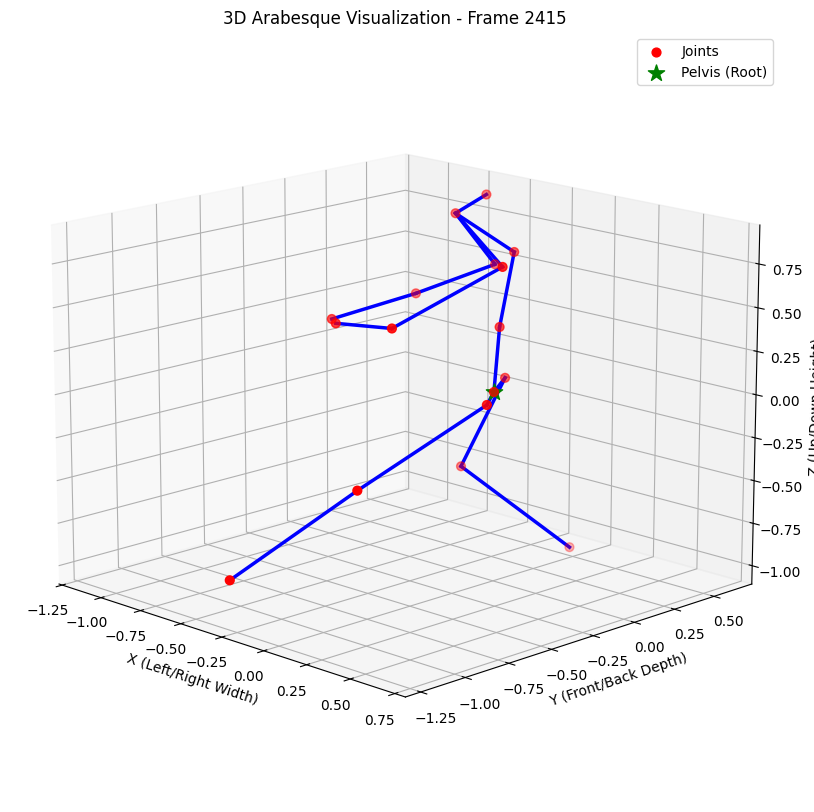

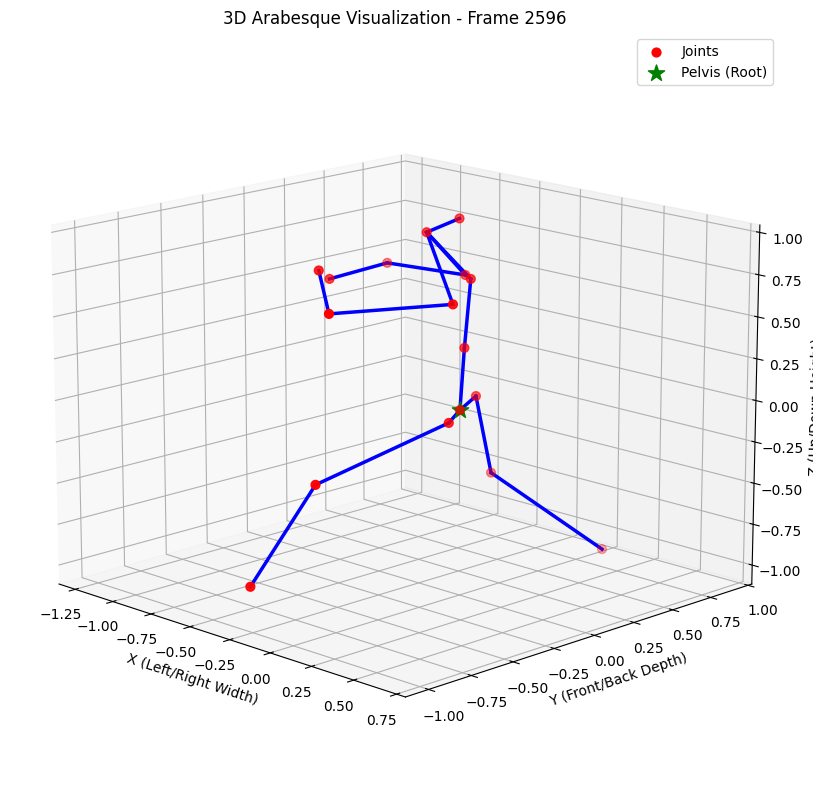

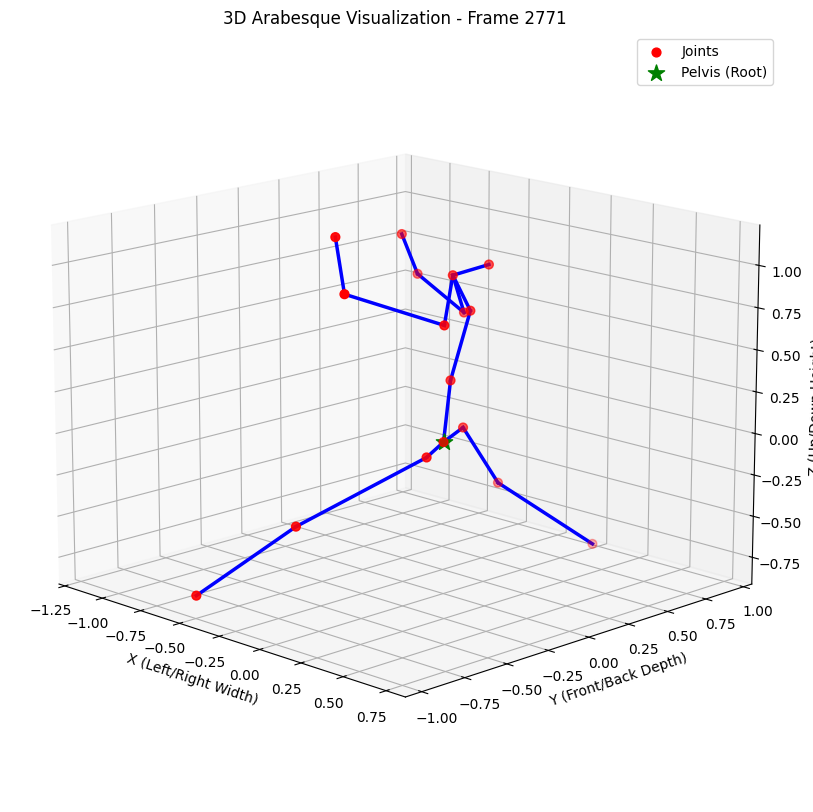

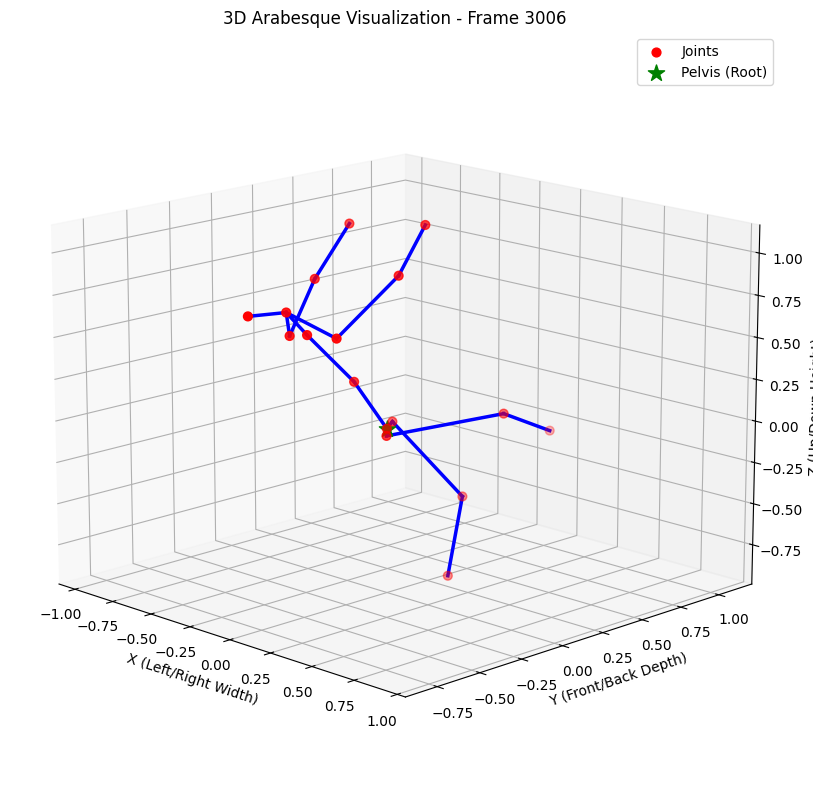

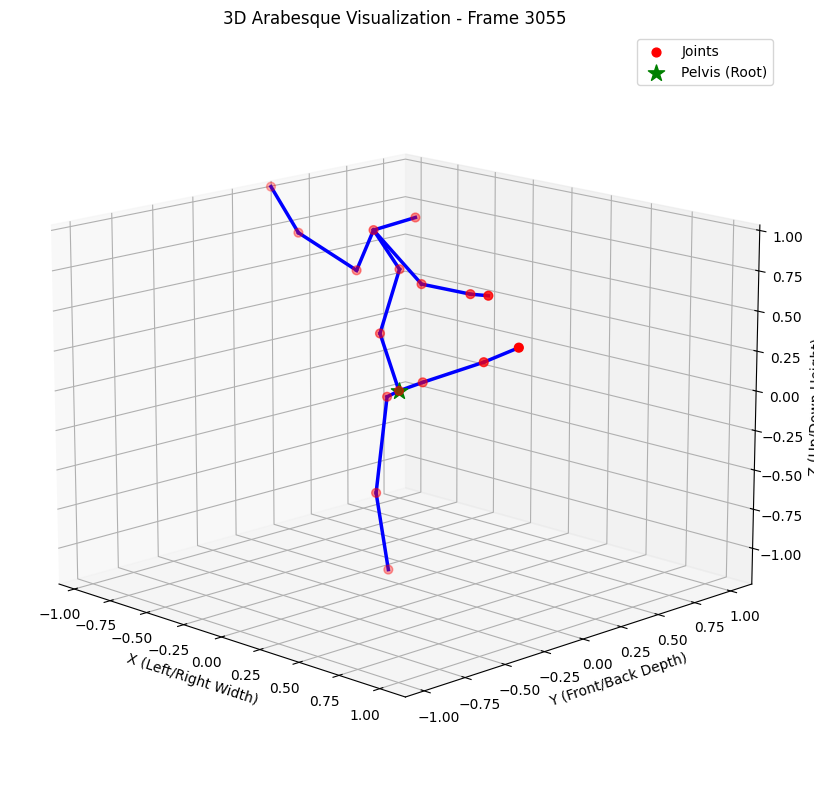

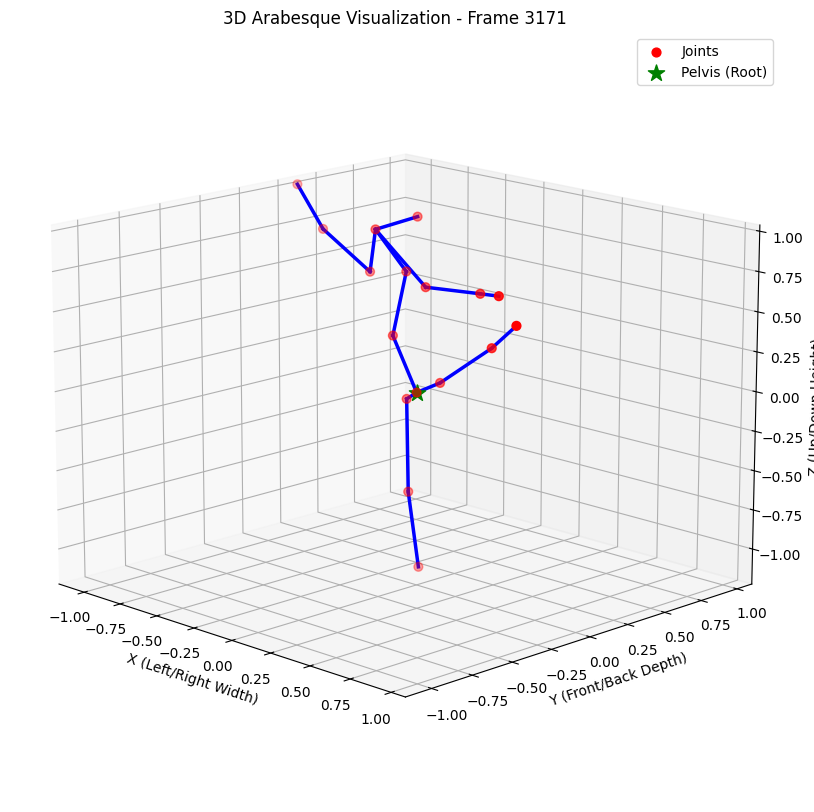

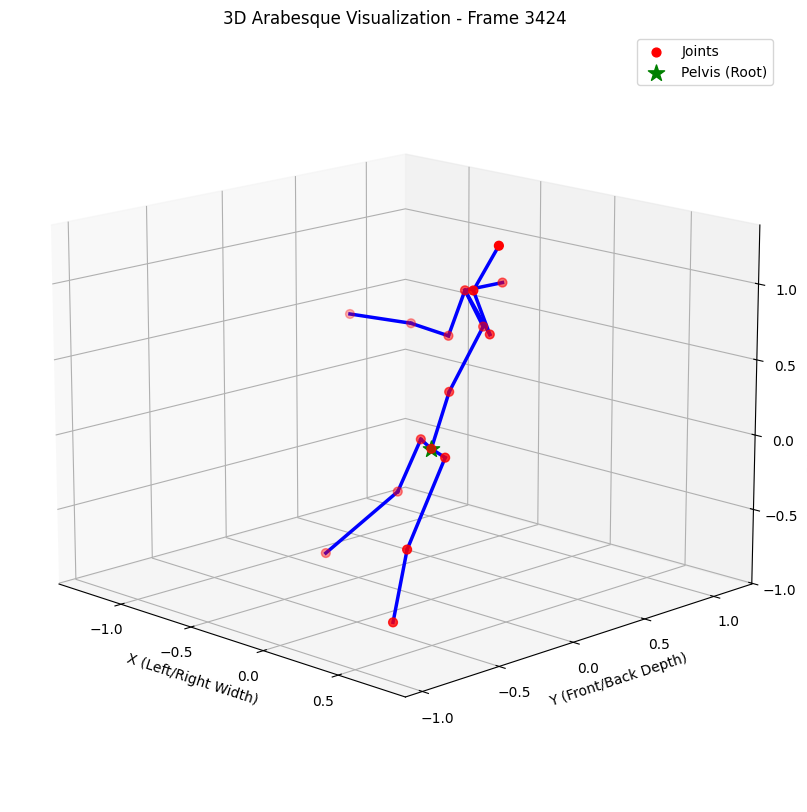

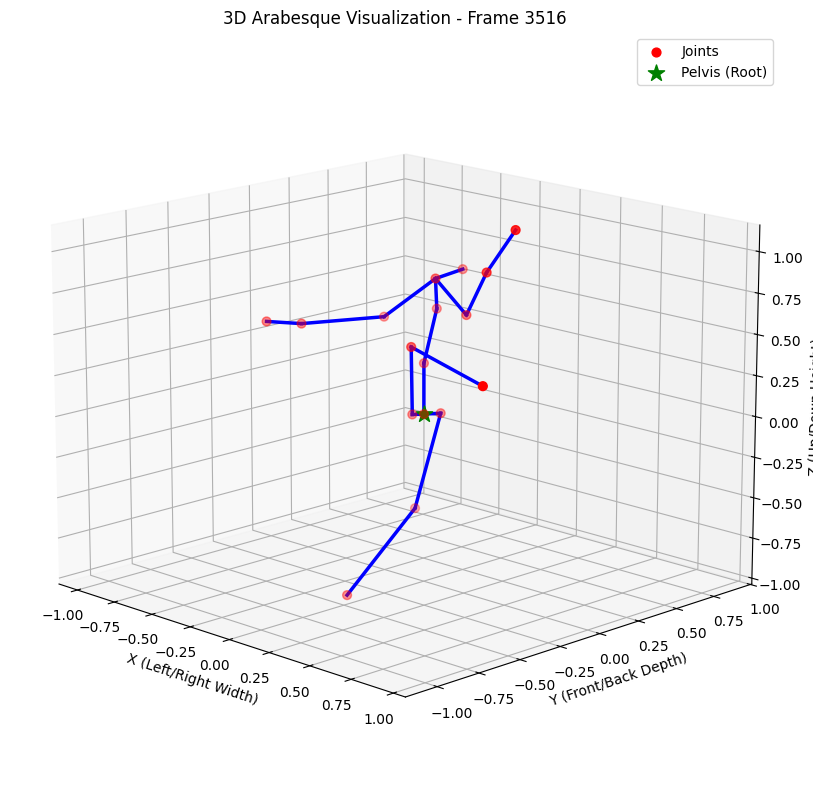

   ✅ Saved 17 frames to ./results\frames
   ✅ Saved metrics to ./results\Jingxinyu.mp4_arabesque_metrics.csv



In [12]:
for idx, video_path in enumerate(video_files):
    vid_name = os.path.basename(video_path)
    
    # Detect dynamic FPS for current video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps < 1: fps = 30.0 # Fallback for corrupted metadata
    cap.release()
    
    print(f"\n[{idx+1}/{len(video_files)}] Processing Video: {vid_name} (FPS: {fps:.2f})")
    
    # Step 1: Audio Cropping
    y, sr, total_duration = audio_sync.extract_audio_array(video_path)
    music_start_sec = audio_sync.find_music_start_time(y, sr)
    music_end_sec = audio_sync.find_music_end_time(y, sr, total_duration, buffer_sec=1)
    temp_video_path = f"temp_trim_{vid_name}"
    
    try:
        print("   ✂️ Cropping pre-performance noise...")
        clip = VideoFileClip(video_path)
        trimmed_clip = clip.subclip(music_start_sec, music_end_sec)
        trimmed_clip.write_videofile(temp_video_path, codec="libx264", audio=True, logger=None)
        clip.close()
        
        # Step 2: 2D&3D Pose Inference (Bulletproof generator)
        print("   🦴 Extracting 3D Spatial Coordinates...")
        inferencer_3d = MMPoseInferencer(pose3d='human3d', device='cuda:0')
        all_3d_keypoints = []
        frozen_frames_count = 0
    
        for result in inferencer_3d(temp_video_path):
            preds = result.get('predictions', [])
            if len(preds) > 0 and len(preds[0]) > 0:
                all_3d_keypoints.append(preds[0][0]['keypoints'])
                frozen_frames_count = 0
            else:
                all_3d_keypoints.append(all_3d_keypoints[-1] if all_3d_keypoints else np.zeros((17, 3)))
                frozen_frames_count += 1
                
                if frozen_frames_count > 5:
                    print(f"      🚨 WARNING: 3D Model lost tracking for {frozen_frames_count} frames! Producing Zombie Frames!")

        skeletons_3d = np.array(all_3d_keypoints)
        
        print(f"   ✅ Synchronized {len(skeletons_3d)} frames. 3D Shape: {skeletons_3d.shape[1:]})")
        
        if len(skeletons_3d) < 30:
            print("   ⏭️ Video too short after cropping. Skipping.")
            continue
            
        normalizer = SpatialNormalizer()
        skels_norm = normalizer.normalize_sequence(skeletons_3d)

        detector = ArabesquePeakDetector(fps=fps)
        peaks = detector.detect_peaks(skels_norm, score_threshold=0.4)
        
        if not peaks:
            print("   ⚠️ No Arabesque movements detected above threshold.")
            
        print(f"   🎯 Found {len(peaks)} Arabesque peaks. Saving data...")
        
        # Prepare list to store data for CSV
        csv_data = []
        frames_output_dir = os.path.join(output_folder, "frames")
        
        for i, peak in enumerate(peaks):
            # Extract, visualize, and save the frame
            img_path = ArabesqueVisualizer.extract_and_save_peak_frame(
                video_path=temp_video_path,
                output_dir=frames_output_dir,
                peak_data=peak,
                base_filename=f"{vid_name}_peak_{i}"
            )
            
            # Flatten the dictionary for CSV export
            row_data = {
                'video': vid_name,
                'peak_id': i,
                'frame_idx': peak['frame_idx'],
                'timestamp_sec': peak['timestamp'],
                'total_score': peak['score'],
                'image_path': img_path
            }
            # Merge metrics into the row
            row_data.update(peak['metrics'])
            csv_data.append(row_data)

            visualize_3d_skeleton(skels_norm[peak['frame_idx']], peak['frame_idx'])

        # 4. Save metrics to CSV using Pandas
        df = pd.DataFrame(csv_data)
        csv_path = os.path.join(output_folder, f"{vid_name}_arabesque_metrics.csv")
        df.to_csv(csv_path, index=False, encoding='utf-8')
        
        print(f"   ✅ Saved {len(peaks)} frames to {frames_output_dir}")
        print(f"   ✅ Saved metrics to {csv_path}\n")
                
    except Exception as e:
        print(f"   ❌ Fatal error processing {vid_name}: {e}")
        continue
        
    finally:
        # Clean up temporary cropped video to save disk space
        if os.path.exists(temp_video_path):
            os.remove(temp_video_path)
            